In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers

In [34]:
# 1.1 Read "Breast Cancer Wisconsin" Dataset from CSV file

def read_csv_file(file_path):
    try:
        df = pd.read_csv(file_path)
        return df
    except FileNotFoundError:
        print(f'Error: File "{file_path}" is not found.')
        return None
    except Exception as error:
        print(f'An unexpected error occurred: {error}')
        return None
#-----------------------------------------------------
# Call Function and read data
#-----------------------------------------------------
df=read_csv_file('data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [35]:
def explore_dataset(df):

    print(f"{'=' * 20} Initial dataset analysis:{'=' * 20}\n")

    # 1. General DataFrame information (dimensions, data types, and non-null values)
    print("--- DataFrame Info ---")
    df.info()
    print("\n" + "-" * 50)

    # 2. Number and percentage of missing data in each column
    print("--- Missing Values ---")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_summary = pd.DataFrame(
        {"Missing number": missing, "The Missing Percentage": missing_pct.round(2)}
    )
    print(missing_summary)
    print("\n" + "-" * 50)

    # 3. Number of duplicate rows
    print("--- Duplicate Rows ---")
    duplicate_count = df.duplicated().sum()
    print(f"Total number of duplicate rows: {duplicate_count}")
    print("\n" + "-" * 50)

    # 4 and 5. Data type and number of unique values for each column
    print("--- Column Summary (Data Types and Unique Values) ---")
    col_summary = pd.DataFrame(
        {"Data Type (Dtype)": df.dtypes, "Number of unique values": df.nunique()}
    )
    print(col_summary)
    print("\n" + "=" * 60)

#---------------------
# Call Function 
#---------------------
explore_dataset(df)

==================== Initial dataset analysis:====================

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    fl

<div dir="rtl" style="text-align: right;">
    
##### ارزیابی خروجی مجموعه داده (مجموعه داده سرطان پستان ویسکانسین) - ابعاد داده:
1. این مجموعه داده شامل ۵۶۹ رکورد (سطر) و ۳۳ ستون است.
2. **مقادیر مفقود (Missing Values):** تقریباً تمام ستون‌های ویژگی (feature) فاقد مقادیر مفقود هستند (۰٫۰٪)، به استثنای یک ستون در انتهای مجموعه داده.
3. **ستون (Unnamed: 32):** این ستون کاملاً خالی است (تمام ۵۶۹ مقدار آن NaN هستند) و باید با استفاده از دستور `df.drop(columns=['Unnamed: 32'])` حذف شود.
4. **ستون شناسه (id):** شامل ۵۶۹ مقدار منحصر‌به‌فرد است که با تعداد کل سطرها مطابقت دارد؛ این ستون فاقد قدرت پیش‌بینی است و باید پیش از مدل‌سازی یادگیری ماشین حذف شود.
5. **سطرهای تکراری:** دقیقاً ۰ سطر تکراری شناسایی شد که نشان‌دهنده یکپارچگی و صحت بالای داده‌هاست.
6. **متغیر هدف (diagnosis):** دارای نوع داده Object و دقیقاً ۲ مقدار منحصر‌به‌فرد (مسئله طبقه‌بندی دودویی) است که در خط لوله پیش‌پردازش نیاز به کدگذاری عددی (مانند label encoding یا one-hot encoding) دارد.
7. **ستون‌های ویژگی :** ۳۰ ستون باقی‌مانده همگی ویژگی‌های عددی پیوسته (float64) با تعداد زیادی مقدار منحصر‌به‌فرد هستند و برای تحلیل آماری و مقیاس‌بندی (scaling) آماده‌اند. </div>


In [37]:
# Remove completely empty column
df = df.drop(columns=['Unnamed: 32'])
print("New dimensions of the DataFrame:", df.shape)


New dimensions of the DataFrame: (569, 32)


In [38]:
# Numerical data
# Select all numerical columns except the 'id' column
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')

print(f"Number of numerical features: {len(numerical_cols)}")

Number of numerical features: 30


--- Target Distribution ---
           Count Percentage
diagnosis                  
B            357     62.74%
M            212     37.26%


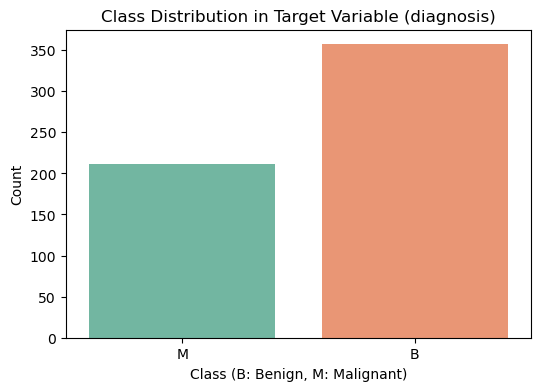

In [36]:
# 1. Calculating the count and percentage of each class in the target variable
counts = df['diagnosis'].value_counts()
percentages = df['diagnosis'].value_counts(normalize=True) * 100

# Creating a Summary Table
target_distribution = pd.DataFrame({
    'Count': counts,
    'Percentage': percentages.round(2).astype(str) + '%'
})

print("--- Target Distribution ---")
print(target_distribution)

# 2. Plotting a chart to visualize class balance

plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', hue='diagnosis', data=df, palette='Set2', legend=False)
plt.title('Class Distribution in Target Variable (diagnosis)')
plt.xlabel('Class (B: Benign, M: Malignant)')
plt.ylabel('Count')
plt.show()

<div dir="rtl" style="text-align: right;">

### تحلیل توزیع متغیر هدف (Target Distribution Analysis)

<!-- **توزیع آماری نمونه‌ها:**   -->

- **کلاس خوش‌خیم (B - Benign):** ۳۵۷ نمونه (معادل **۶۲٫۷۴٪**)  
- **کلاس بدخیم (M - Malignant):** ۲۱۲ نمونه (معادل **۳۷٫۲۶٪**)  

<!-- **تفسیر و تأثیرات بر روند مدل‌سازی:**   -->

- **عدم تعادل ملایم (Mild Imbalance):** نسبت تقریبی کلاس‌ها حدود ۶۳ به ۳۷ درصد است. اگرچه عدم تعادل کلاس‌ها شدید نیست (نیاز به تکنیک‌های تهاجمی Oversampling مانند SMOTE احساس نمی‌شود)، اما برای جلوگیری از بایاس مدل به سمت کلاس اکثریت، ملاحظاتی ضروری است.  
- **لزوم استفاده از نمونه‌گیری لایه‌ای (Stratified Splitting):** هنگام تقسیم داده‌ها به مجموعه‌های آموزش و آزمون (`train_test_split`)، حتماً باید از پارامتر `stratify=y` استفاده شود تا نسبت ۶۳/۳۷ در هر دو مجموعه حفظ شود.  
- **کفایت معیار Accuracy:** به دلیل این عدم تعادل، دقت مدل (`Accuracy`) به‌تنهایی نمی‌تواند معیار کافی برای ارزیابی بالینی باشد؛ اولویت اصلی در مسائل پزشکی بهینه‌سازی معیارهای `Recall` (کاهش موارد منفی کاذب برای بیماران بدخیم)، `F1-Score` و `AUC-ROC` خواهد بود.

</div>

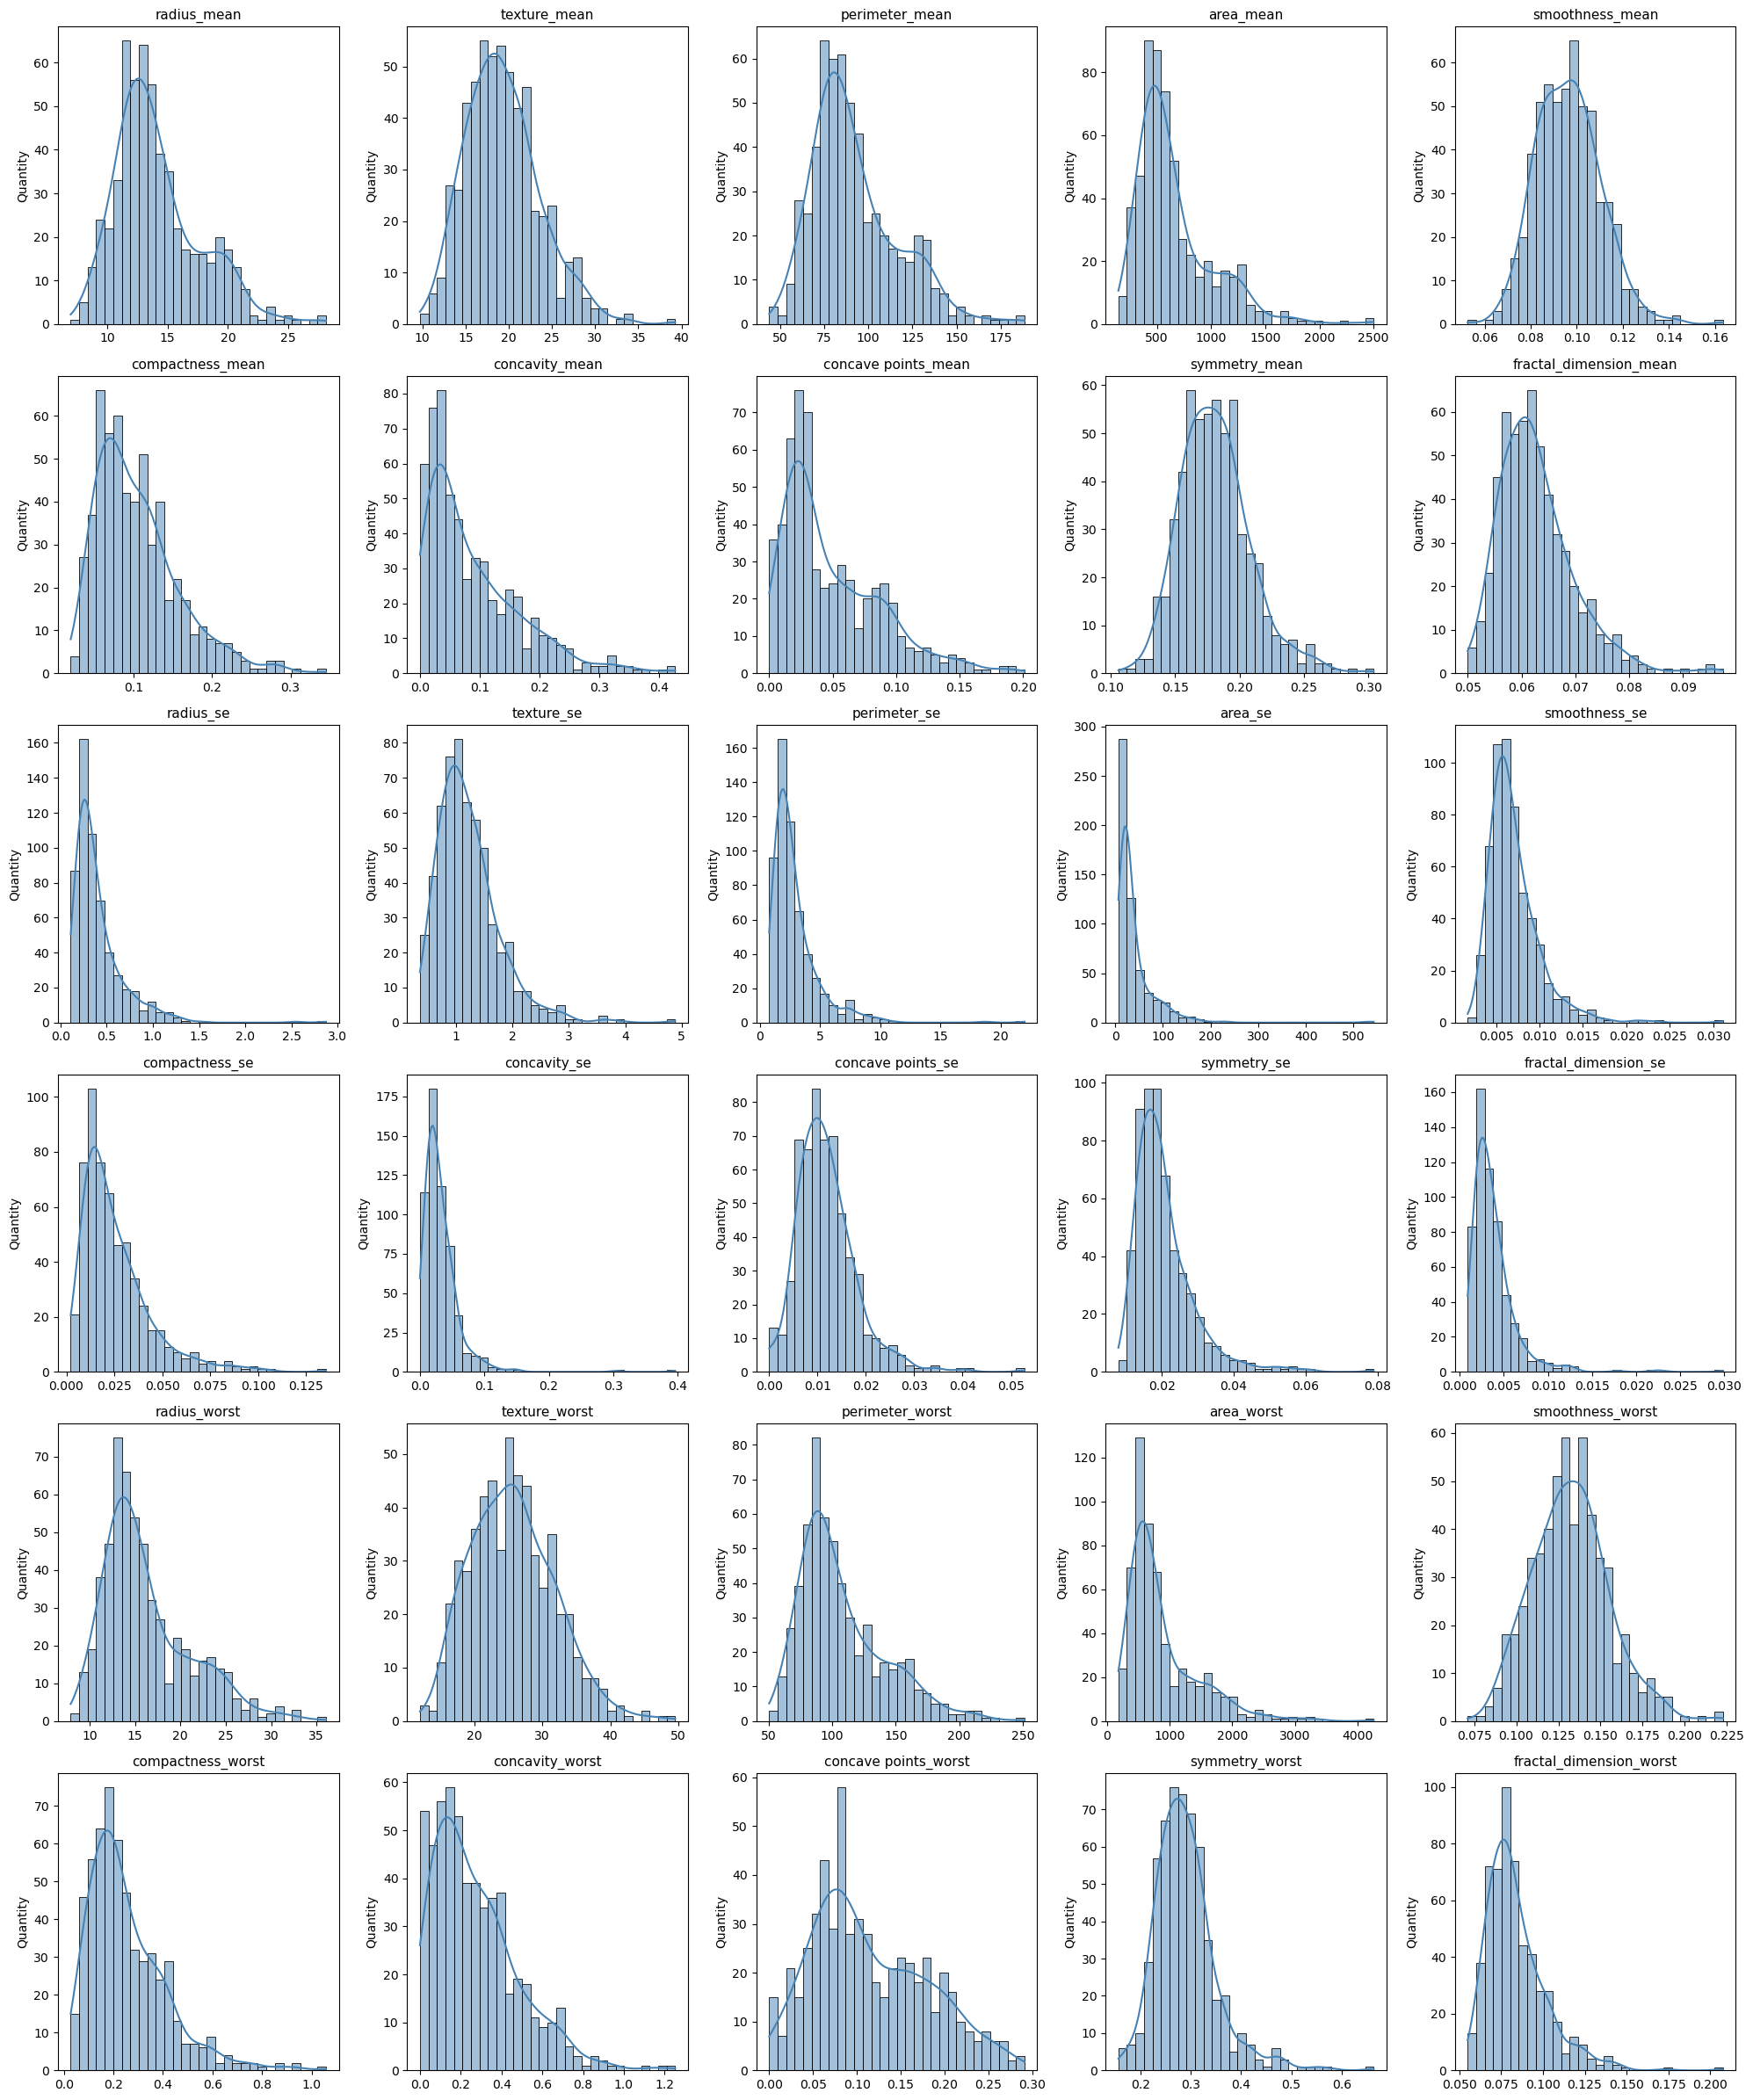

In [39]:
def plot_numerical_histograms(df, numerical_cols, bins=30):

    n_cols = 5
    n_rows = math.ceil(len(numerical_cols) / n_cols)
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()  
    
    for i, col in enumerate(numerical_cols):
        sns.histplot(df[col], bins=bins, kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Quantity')
    
    # Turning off remaining empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()
# TODO: از تابع نوشته استفاده کنید و هیستوگرام ویژگی های عددی را رسم کنید
plot_numerical_histograms(df, numerical_cols, bins=30)

<div dir="rtl" style="text-align: right; direction: rtl; font-family: Tahoma, sans-serif; line-height: 1.8;">

<h3 style="text-align: right; margin-bottom: 15px;">تحلیل و تفسیر هیستوگرام توزیع ویژگی‌ها</h3>

<ul style="direction: rtl; text-align: right; padding-right: 20px; list-style-position: inside;">
  <li style="margin-bottom: 15px;">
    <strong>توزیع‌های نرمال / زنگوله‌ای شکل:</strong><br>
    <strong>ویژگی‌ها:</strong> میانگین بافت، میانگین همواری، میانگین تقارن و نسخه‌های worst مربوط به آن‌ها.<br>
    <strong>تفسیر:</strong> نقاط داده به صورت متقارن حول میانگین با دنباله‌های متعادل توزیع شده‌اند که نشان‌دهنده توزیع نرمال گاوسی در ویژگی‌های بیولوژیکی است.
  </li>

  <li style="margin-bottom: 15px;">
    <strong>توزیع‌های چوله به راست / چوله مثبت:</strong><br>
    <strong>ویژگی‌ها:</strong> تمام معیارهای خطای استاندارد (پسوند <code>_se</code> مانند <code>area_se</code> و <code>radius_se</code>)، ابعاد مساحت (<code>area_mean</code> و <code>area_worst</code>) و تقعر (<code>concavity_mean</code>).<br>
    <strong>تفسیر:</strong> اکثریت نمونه‌ها در مقادیر پایین متمرکز هستند، در حالی که دنباله بلند سمت راست نشان‌دهنده نمونه‌های شدید و داده‌های پرت (Outliers) است.
  </li>

  <li style="margin-bottom: 15px;">
    <strong>گرایش‌های دووجهی / چندوجهی:</strong><br>
    <strong>ویژگی‌ها:</strong> به‌ویژه در نقاط مقعر (<code>concave points_mean</code> و <code>concave points_worst</code>).<br>
    <strong>تفسیر:</strong> وجود دو قله متمایز نشان‌دهنده جدایی طبیعی کلاس‌های خوش‌خیم و بدخیم است و قدرت تفکیک بالای این ویژگی‌ها را اثبات می‌کند.
  </li>

  <li style="margin-bottom: 15px;">
    <strong>تفاوت‌های مقیاس قابل توجه:</strong><br>
    <strong>تفسیر:</strong> دامنه تغییرات از ۰٫۰۵ در <code>smoothness_mean</code> تا بالای ۴۰۰۰ در <code>area_worst</code> متغیر است؛ لذا استفاده از مقیاس‌بندی (مانند <code>StandardScaler</code>) قبل از مدل‌سازی الزامی است.
  </li>
</ul>

</div>

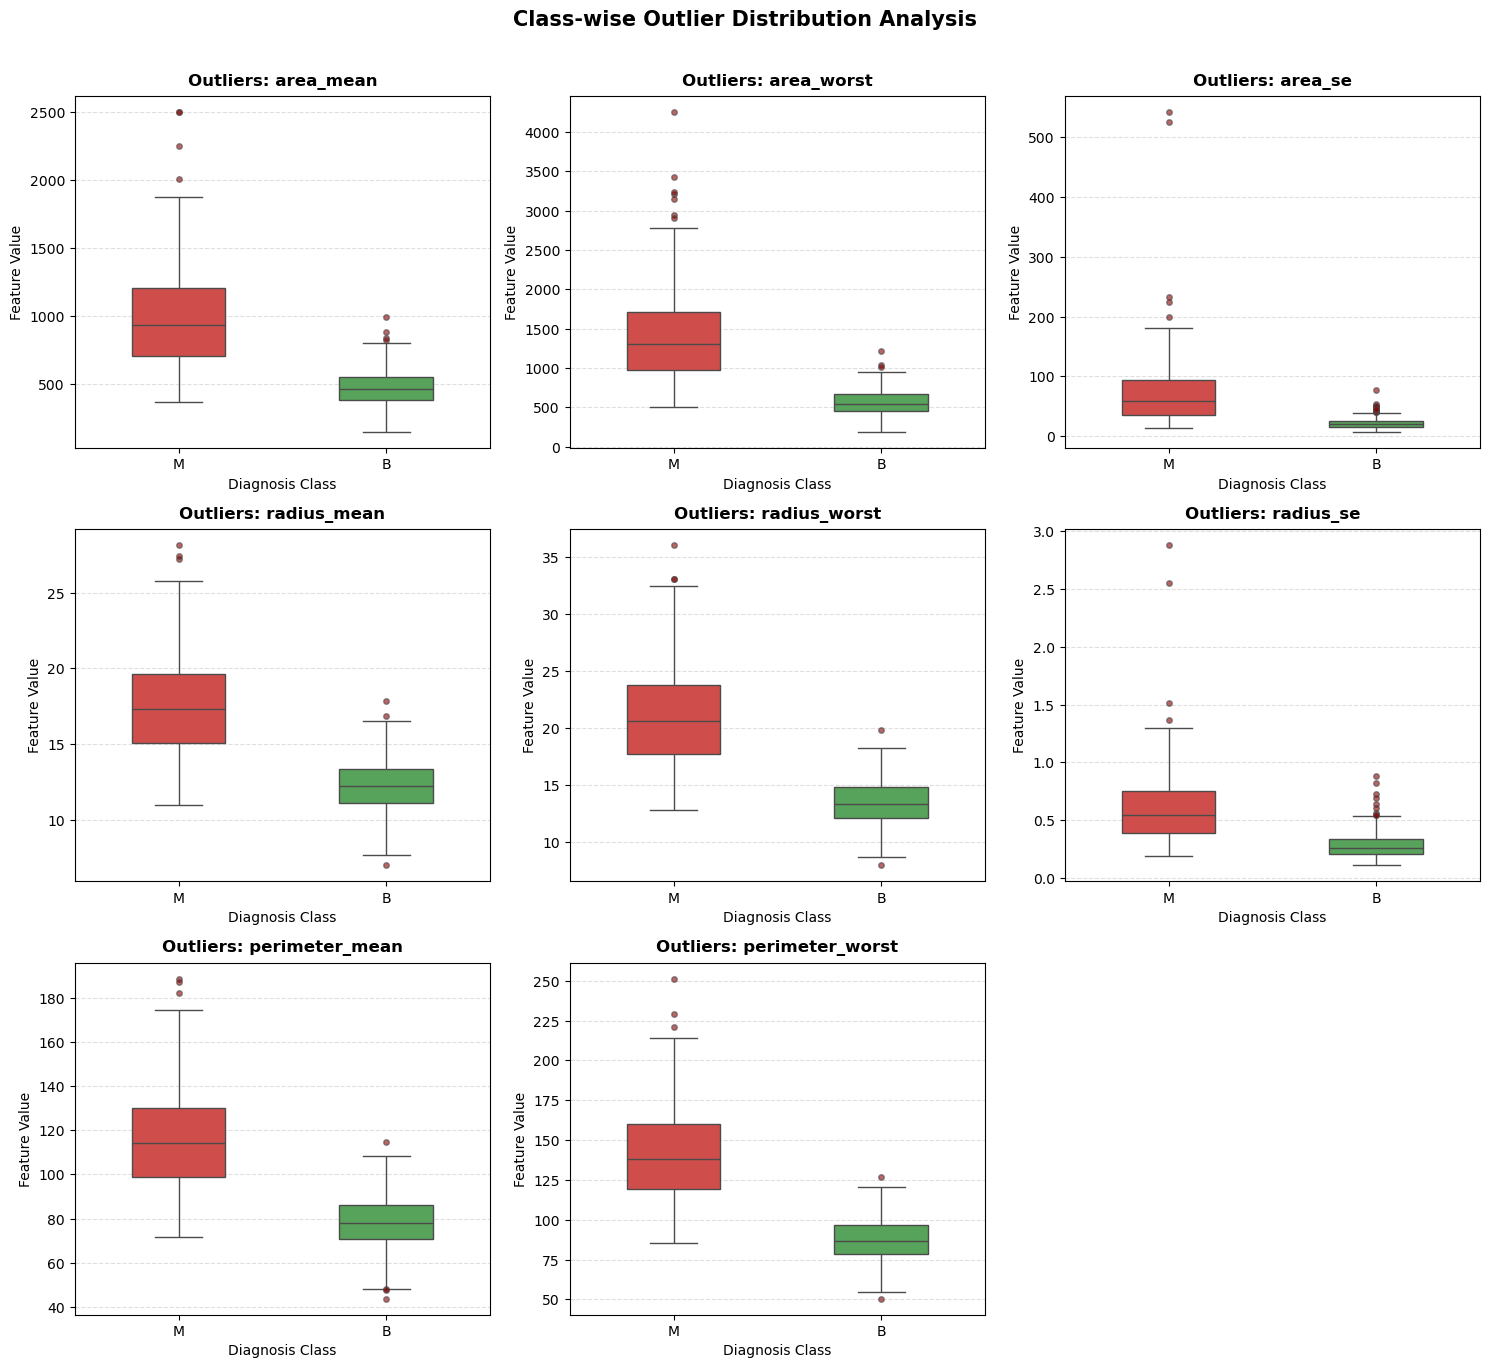

In [76]:
def plot_outliers_by_class(df, features, target_col='diagnosis', n_cols=3):
    
    valid_features = [f for f in features if f in df.columns]
    n_features = len(valid_features)
    
    if n_features == 0:
        print("No valid feature found for plotting.")
        return

    n_rows = math.ceil(n_features / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    
    if n_features == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    palette = {'B': '#4CAF50', 'M': '#E53935'} if set(df[target_col].unique()) == {'B', 'M'} else 'Set2'

    for i, col in enumerate(valid_features):
        ax = axes[i]
        
        sns.boxplot(
            data=df, 
            x=target_col, 
            y=col, 
            hue=target_col, 
            palette=palette,
            legend=False,
            ax=ax, 
            width=0.45,
            fliersize=4,
            flierprops={'marker': 'o', 'markerfacecolor': 'darkred', 'alpha': 0.6}
        )
        
        ax.set_title(f'Outliers: {col}', fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel('Diagnosis Class', fontsize=10)
        ax.set_ylabel('Feature Value', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4, axis='y')

    for j in range(n_features, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Class-wise Outlier Distribution Analysis', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


key_outlier_features = [
    'area_mean', 'area_worst', 'area_se',
    'radius_mean', 'radius_worst', 'radius_se',
    'perimeter_mean', 'perimeter_worst'
]

plot_outliers_by_class(df, features=key_outlier_features, target_col='diagnosis', n_cols=3)

<div dir="rtl" style="text-align: right;">

### تحلیل و تفسیر توزیع داده‌های پرت به تفکیک کلاس (Class-wise Outlier Analysis)

<!-- **مشاهدات کلیدی از نمودارهای جعبه‌ای:**   -->
- **تفکیک‌پذیری قوی بین دو کلاس:** در تمام ویژگی‌های ابعادی (`area`، `radius`، `perimeter`) میانه و چارک‌های کلاس بدخیم (M) به طور چشمگیری بالاتر از کلاس خوش‌خیم (B) قرار دارد که نشان‌دهنده پتانسیل بالای این متغیرها در پیش‌بینی است.  
- **توزیع و غلظت داده‌های پرت (Outliers):**  
  - اکثریت قریب به اتفاق داده‌های پرت شدید (نقاط قرمز بالای نمودارها) متعلق به **کلاس بدخیم (M)** هستند؛ به‌ویژه در معیارهای مقیاس مانند `area_mean` (بالای ۲۰۰۰)، `area_worst` (تا بالای ۴۰۰۰) و خطای استاندارد `area_se` (بالای ۵۰۰).  
  - کلاس خوش‌خیم (B) پراکندگی بسیار فشرده‌تر و داده‌های پرت محدودی دارد که عمدتاً نزدیک به مرز مجاز چارک‌ها هستند.  

<!-- **ملاحظات و تصمیمات پیش‌پردازش (ML Implications):**   -->
- **ماهیت واقعی داده‌های پرت بالینی (True Biological Outliers):** این نقاط خطای اندازه‌گیری یا نویز تصادفی نیستند، بلکه نشان‌دهنده تومورهای پیشرفته و بسیار بزرگ در بیماران بدخیم هستند؛ بنابراین **حذف یا برش (Trim) آن‌ها باعث از دست رفتن اطلاعات حیاتی پزشکی می‌شود و نباید حذف شوند.**  
- **الزام مقیاس‌بندی مناسب:** با توجه به بازه وسیع و حضور مقادیر حدی شدید، مقیاس‌بندی استاندارد داده‌ها (`StandardScaler` یا در موارد حساس‌تر `RobustScaler`) جهت جلوگیری از انحراف وزن‌ها در شبکه عصبی مصنوعی (ANN) ضروری است.

</div>

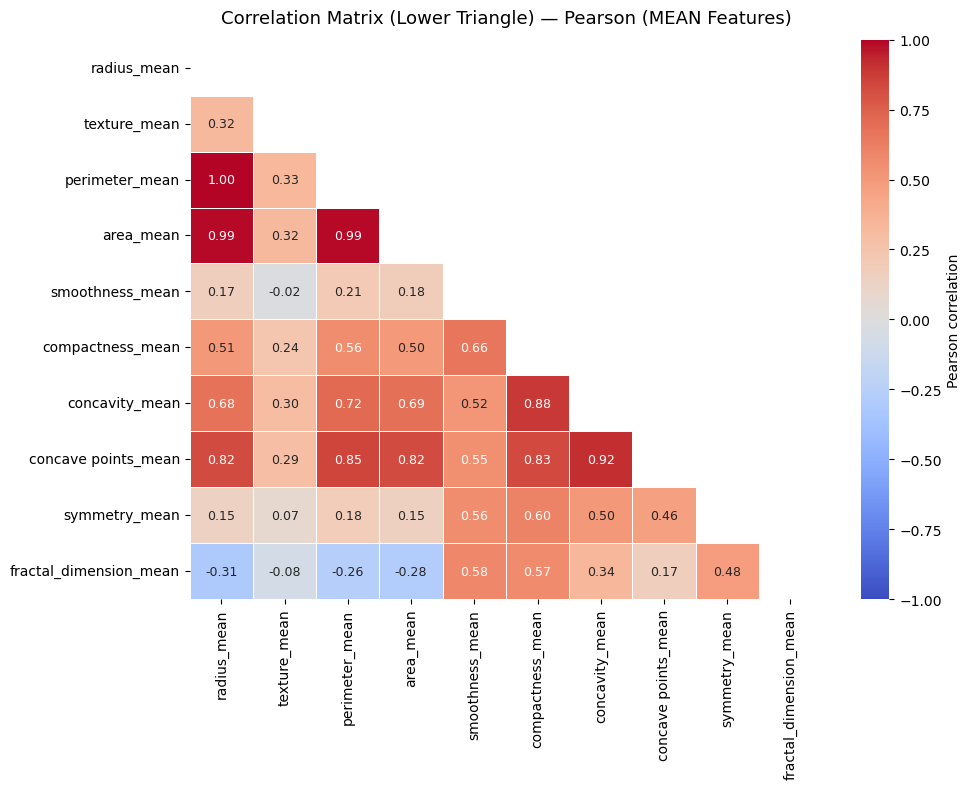

In [74]:
def plot_corr_lower_pearson(df, feature_group='mean'):

    # 1. Filtering ID columns and text/empty columns
    numeric_df = df.select_dtypes(include=['float64', 'int64'])
    numeric_df = numeric_df.drop(columns=[col for col in ['id', 'Unnamed: 32'] if col in numeric_df.columns])

    # 2. Selecting the desired group for better readability of numerical values in the heatmap
    if feature_group in ['mean', 'worst', 'se']:
        target_cols = [col for col in numeric_df.columns if f'_{feature_group}' in col]
        plot_data = numeric_df[target_cols]
    else:
        plot_data = numeric_df

    # 3. Calculation of the Pearson correlation matrix
    corr = plot_data.corr(method='pearson')

    # 4. Creating a mask to hide the upper triangle of the matrix.
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # 5. Plotting a Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        vmin=-1, 
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 9},
        cbar_kws={'label': 'Pearson correlation'}
    )

    title_suffix = f"({feature_group.upper()} Features)" if feature_group != 'all' else "(All Features)"
    plt.title(f'Correlation Matrix (Lower Triangle) — Pearson {title_suffix}', fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()


plot_corr_lower_pearson(df, feature_group='mean')

<div dir="rtl" style="text-align: right;">

### تحلیل ماتریس همبستگی پیرسون (Pearson Correlation Matrix - Mean Features)

<!-- **مشاهدات کلیدی و تحلیل آماری:**   -->
- **چندهم‌خطی شدید در ویژگی‌های ابعادی (Extreme Multicollinearity):**  
  همبستگی میان سه ویژگی `radius_mean`، `perimeter_mean` و `area_mean` تقریباً برابر با **۱٫۰۰ و ۰٫۹۹** است. این همبستگی خطی کامل نشان می‌دهد که هر سه متغیر بیانگر یک مفهوم فیزیکی یکسان (اندازه تومور) هستند و نگه‌داشتن هم‌زمان آن‌ها افزونگی داده‌ای (Data Redundancy) شدید ایجاد می‌کند.  
- **همبستگی بالا در معیارهای شکل و تقعر:**  
  ارتباط بسیار قوی میان `concavity_mean` و `concave points_mean` (**۰٫۹۲**) و همچنین `compactness_mean` با `concavity_mean` (**۰٫۸۸**) مشاهده می‌شود که نشان‌دهنده هم‌پوشانی زیاد در ثبت بی‌نظمی مرزهای سلولی است.  
- **استقلال نسبی ویژگی‌های بافت و بعد فرکتال:**  
  ویژگی `texture_mean` و `fractal_dimension_mean` همبستگی پایینی با معیارهای اندازه دارند (بین **۰٫۰۸- تا ۰٫۳۳**)، که نشان می‌دهد اطلاعات ساختاری مجزا و مستقلی را به مدل اضافه می‌کنند.

<!-- **توجیه مهندسی ویژگی‌ها و اقدامات آتی (Feature Engineering Rationale):**   -->
- **توجیه ایجاد ویژگی‌های هندسی و ترکیبی:** وجود همبستگی‌های نزدیک به ۱ دلیل اصلی نیاز به ساخت نسبت‌ها (مانند نسبت مساحت به محیط) و شاخص‌های ترکیبی است تا ابعاد هندسی و شکل تومور جایگزین مقادیر مطلق تکراری شوند.  
- **کاهش ابعاد و حذف ویژگی‌های مازاد (Feature Dropping):** برای جلوگیری از ناپایداری وزن‌های شبکه عصبی مصنوعی (ANN) و بهبود سرعت همگرایی، متغیرهای بسیار همبسته پس از استخراج ویژگی‌های ترکیبی از مجموعه داده حذف می‌شوند.

</div>

In [41]:
df_copy = df.copy()

In [42]:
# Area-to-Perimeter Ratio
df_copy['area_to_perimeter'] = df_copy['area_mean'] / df_copy['perimeter_mean']

# Ratio of area to radius
df_copy['area_to_radius'] = df_copy['area_mean'] / df_copy['radius_mean']

# Ratio of circumference to radius
df_copy['perimeter_to_radius'] = df_copy['perimeter_mean'] / df_copy['radius_mean']

In [43]:
# Key geometric features for calculating the difference
features_to_diff = ['radius', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'symmetry']

for feat in features_to_diff:
    worst_col = f"{feat}_worst"
    mean_col = f"{feat}_mean"
    diff_col = f"{feat}_diff"
    
    df_copy[diff_col] = df_copy[worst_col] - df_copy[mean_col]

print("New features were successfully added. New DataFrame dimensions:", df_copy.shape)

New features were successfully added. New DataFrame dimensions: (569, 42)


In [44]:
# Calculating the ratio of standard deviation to the mean

df_copy['radius_rse'] = df_copy['radius_se'] / df_copy['radius_mean']
df_copy['area_rse'] = df_copy['area_se'] / df_copy['area_mean']
df_copy['perimeter_rse'] = df_copy['perimeter_se'] / df_copy['perimeter_mean']

In [45]:
# Geometric Mean for Compactness

df_copy['compactness_geom_mean'] = np.sqrt(df_copy['compactness_mean'] * df_copy['compactness_worst'])

# Geometric mean for other dimensional characteristics with strong correlation
df_copy['radius_geom_mean'] = np.sqrt(df_copy['radius_mean'] * df_copy['radius_worst'])
df_copy['perimeter_geom_mean'] = np.sqrt(df_copy['perimeter_mean'] * df_copy['perimeter_worst'])
df_copy['area_geom_mean'] = np.sqrt(df_copy['area_mean'] * df_copy['area_worst'])

print("Composite features have been added. Current DataFrame dimensions:", df_copy.shape)

Composite features have been added. Current DataFrame dimensions: (569, 49)


In [46]:
# Combination of mean and worst for a normalized feature

features_to_avg = ['radius', 'smoothness', 'symmetry', 'concavity']

for feat in features_to_avg:
    mean_col = f"{feat}_mean"
    worst_col = f"{feat}_worst"
    avg_col = f"avg_{feat}"
    
    df_copy[avg_col] = (df_copy[mean_col] + df_copy[worst_col]) / 2

print("Average features were successfully added.")

Average features were successfully added.


In [47]:
# Remove features
features_to_drop = [
    # Inactive ID column
    'id',
    
    # Initial versions replaced by difference, mean, or ratio
    'radius_mean', 'radius_worst', 'radius_se',
    'perimeter_mean', 'perimeter_worst', 'perimeter_se',
    'area_mean', 'area_worst', 'area_se',
    'compactness_mean', 'compactness_worst',
    'smoothness_mean', 'smoothness_worst', 'smoothness_se',
    'concavity_mean', 'concavity_worst',
    'symmetry_mean', 'symmetry_worst'
]

features_to_drop = [col for col in features_to_drop if col in df_copy.columns]

df_copy = df_copy.drop(columns=features_to_drop)

print("DataFrame dimensions after removing duplicate features:", df_copy.shape)

DataFrame dimensions after removing duplicate features: (569, 34)


In [49]:
# Converting 'diagnosis' to a number

df_copy['diagnosis'] = df_copy['diagnosis'].map({'B': 0, 'M': 1})
print(df_copy['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [50]:
# Split X and y into dependent and independent variables.
X = df_copy.drop(columns=['diagnosis'])
y = df_copy['diagnosis']

print("Dimensions of feature variables (X):", X.shape)
print("Variable target dimensions(y):", y.shape)

Dimensions of feature variables (X): (569, 33)
Variable target dimensions(y): (569,)


In [51]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Feature Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Number of training data: {X_train.shape[0]} | Number of test data: {X_test.shape[0]}")

Number of training data: 455 | Number of test data: 114


<h3 dir="rtl" style="text-align: right;">چرا به‌جای MinMaxScaler از StandardScaler استفاده شد؟</h3>

<p dir="rtl" style="text-align: right; line-height: 1.8;">
<b>۱. حضور داده‌های پرت (Outliers):</b><br>
در هیستوگرام‌ها و نمودارهای جعبه‌ای مشخص شد متغیرهایی مانند <code>area_worst</code> و <code>area_se</code> دارای کشیدگی شدید به راست هستند. مقیاس‌بند MinMaxScaler تمام داده‌ها را به بازه فشرده [0, 1] می‌برد؛ در نتیجه وجود چند داده پرت باعث می‌شود اکثریت مطلق داده‌های نرمال در یک بازه بسیار فشرده و کوچک (مثلاً ۰ تا ۰٫۰۵) محصور شوند و واریانس واقعی ویژگی‌ها کم شود.
</p>

<p dir="rtl" style="text-align: right; line-height: 1.8;">
<b>۲. حفظ توزیع‌های زنگوله‌ای (گاوسی):</b><br>
بسیاری از ویژگی‌های بیولوژیکی ساختار شبه‌نرمال دارند. تبدیل استانداردساز با فرمول z = (x - μ) / σ داده‌ها را حول میانگین صفر و واریانس یک تنظیم می‌کند این امر شکل اصلی توزیع داده‌ها را حفظ کرده و مقاومت آماری به‌مراتب بالاتری در برابر داده‌های دورافتاده فراهم می‌آورد.
</p>

<p dir="rtl" style="text-align: right; line-height: 1.8;">
<b>۳. بهینه‌سازی پایدار در شبکه عصبی (ANN):</b><br>
در شبکه‌های عصبی مصنوعی، ورودی‌های مقیاس‌شده با میانگین صفر و واریانس واحد از پدیده‌های انفجار یا محوشدگی گرادیان (Gradient Vanishing / Exploding) جلوگیری می‌کنند و همگرایی توابع بهینه‌سازی مبتنی بر گرادیان (مانند Adam) را بسیار سریع‌تر و پایدارتر می‌سازند.
</p>

In [61]:
# Neural network design
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.initializers import HeNormal

def build_model(input_dim):

    model = Sequential([
        # defining input dimensions with the Input layer
        Input(shape=(input_dim,)),
        
        # First hidden layer
        Dense(32, activation='relu', 
              kernel_initializer=HeNormal(),
              kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.3),
        
        # The Second Hidden Layer
        Dense(16, activation='relu', 
              kernel_initializer=HeNormal(),
              kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.2),
        
       # Output layer for binary classification
        Dense(1, activation='sigmoid')
    ])
    
    # Model Compilation
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Model Building
model = build_model(input_dim=X_train.shape[1])

In [63]:
# summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Train the model
history = model.fit(
    X_train, 
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7363 - loss: 0.7293 - val_accuracy: 0.8791 - val_loss: 0.4600
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8159 - loss: 0.4944 - val_accuracy: 0.9121 - val_loss: 0.3451
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8791 - loss: 0.4282 - val_accuracy: 0.9231 - val_loss: 0.2950
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9148 - loss: 0.3391 - val_accuracy: 0.9341 - val_loss: 0.2641
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9093 - loss: 0.3158 - val_accuracy: 0.9341 - val_loss: 0.2474
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9341 - loss: 0.2606 - val_accuracy: 0.9341 - val_loss: 0.2354
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9286 - loss: 0.2661 - val_accuracy: 0.9231 - val_loss: 0.2305
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.2299 - val_accuracy: 0.9341 - val_loss

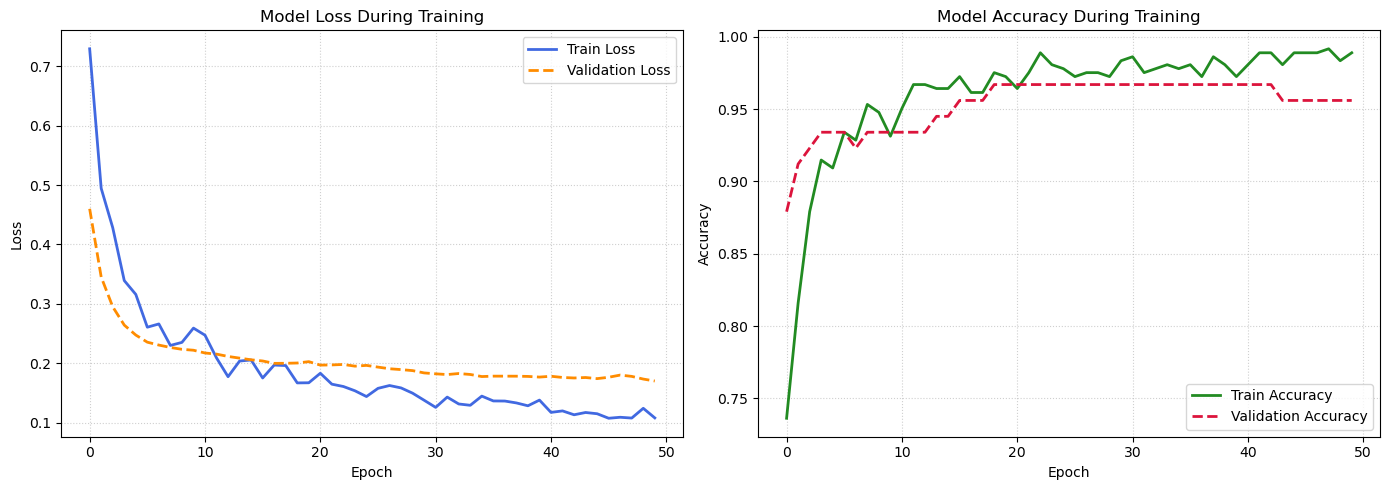

In [65]:
#  Plotting accuracy and loss curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss
ax1.plot(history.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')
ax1.set_title('Model Loss During Training', fontsize=12)
ax1.set_xlabel('Epoch', fontsize=10)
ax1.set_ylabel('Loss', fontsize=10)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='forestgreen', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='crimson', linewidth=2, linestyle='--')
ax2.set_title('Model Accuracy During Training', fontsize=12)
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Accuracy', fontsize=10)
ax2.legend(loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

<h3 dir="rtl" style="text-align: right;">تحلیل منحنی‌های آموزش و اعتبارسنجی مدل (Training & Validation Curves)</h3>

<p dir="rtl" style="text-align: right; line-height: 1.8;">
<b>۱. رفتار تابع زیان (Model Loss):</b><br>
نمودار نشان‌دهنده افت بسیار سریع و مطلوب میزان خطا در هر دو مجموعه داده (Train و Validation) طی ۱۰ تا ۱۵ دوره اولیه (Epoch) است. پس از دوره بیستم، شیب کاهش ملایم‌تر شده و منحنی اعتبارسنجی (خط‌چین نارنجی) بدون هیچ‌گونه جهش صعودی در حوالی مقدار ۰٫۱۸ تثبیت می‌شود. عدم بازگشت به سمت بالا در منحنی خطا نشانه پایدار بودن بهینه‌ساز و عدم وقوع بیش‌برازش شدید (Overfitting) است.
</p>

<p dir="rtl" style="text-align: right; line-height: 1.8;">
<b>۲. روند دقت طبقه‌بندی (Model Accuracy):</b><br>
دقت آموزش (خط سبز) از حدود ۷۳٪ آغاز شده و پس از دور بیستم به بالای ۹۷٪ تا حدود ۹۹٪ می‌رسد. دقت اعتبارسنجی (خط‌چین قرمز) نیز روندی پیوسته و همگام دارد و در بازه زمانی بین دوره‌های ۲۰ تا ۴۰ به دقت پایدار حدود ۹۶٫۵٪ می‌رسد. در انتهای آموزش، اختلاف اندک بین دقت داده‌های آموزش و اعتبارسنجی (حدود ۲ تا ۳ درصد) نشان‌دهنده تعمیم‌پذیری مناسب (Generalization) مدل روی نمونه‌های ندیده است.
</p>

<p dir="rtl" style="text-align: right; line-height: 1.8;">
<b>۳. اثربخشی تکنیک‌های منظم‌سازی (Regularization):</b><br>
همگرایی نرم منحنی‌ها بدون نوسانات شدید تأیید می‌کند که استفاده از منظم‌ساز L2 و لایه‌های Dropout مانع از حفظ کردن نمونه‌ها توسط شبکه عصبی شده است. با توجه به ثبات منحنی‌ها در دوره‌های ۳۵ به بعد، مدل به ظرفیت یادگیری بهینه خود دست یافته و آموزش می‌تواند حول دوره ۳۰ تا ۳۵ متوقف شود.
</p>

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step 
Test AUC-ROC Score: 0.9980

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.99      1.00      0.99        72
Malignant (1)       1.00      0.98      0.99        42

     accuracy                           0.99       114
    macro avg       0.99      0.99      0.99       114
 weighted avg       0.99      0.99      0.99       114



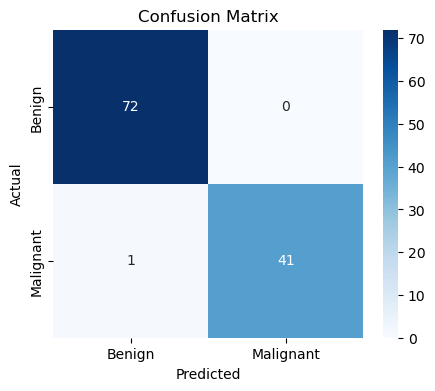

In [69]:
# ارزیابی نهایی مدل بر اساس معیارهای Precision, Recall, F1-score و AUC-ROC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# پیش‌بینی احتمالات و برچسب‌های باینری
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs >= 0.5).astype(int)

# محاسبه و چاپ AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"Test AUC-ROC Score: {roc_auc:.4f}\n")

# چاپ گزارش کامل طبقه‌بندی (Accuracy, Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

# رسم ماتریس درهم‌ریختگی (Confusion Matrix)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

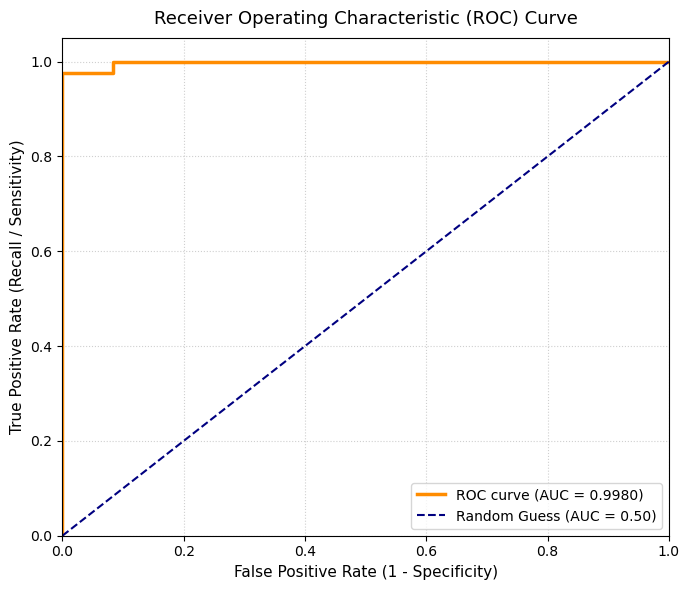

In [77]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculating False Positive Rate (FPR) and True Positive Rate (TPR) values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc_val = auc(fpr, tpr)

# 2. Plotting the ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, pad=10)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

<h3 dir="rtl" style="text-align: right;">ارزیابی عملکرد مدل روی داده‌های آزمون (Model Evaluation & Confusion Matrix)</h3>

<p dir="rtl" style="text-align: right; line-height: 1.8;">
<b>۱. تحلیل ماتریس درهم‌ریختگی (Confusion Matrix):</b><br>
از مجموع ۱۱۴ نمونه داده آزمون:
<br>
• <b>مثبت واقعی (True Negative - Benign):</b> ۷۲ نمونه خوش‌خیم بدون هیچ خطایی، به درستی خوش‌خیم تشخیص داده شده‌اند (نرخ خطای منفی کاذب صفر).<br>
• <b>مثبت واقعی (True Positive - Malignant):</b> ۴۱ نمونه بدخیم از مجموع ۴۲ نمونه به درستی شناسایی شده‌اند.<br>
• <b>منفی کاذب (False Negative):</b> تنها ۱ مورد بدخیم به اشتباه خوش‌خیم پیش‌بینی شده است که نشان‌دهنده حساسیت بسیار بالای مدل در تشخیص بافت‌های سرطانی است.
</p>

<p dir="rtl" style="text-align: right; line-height: 1.8;">
<b>۲. بررسی معیارهای تفکیک بالینی (Classification Metrics):</b><br>
• <b>صحت کلی (Accuracy):</b> مدل به دقت ۹۹٪ (۱۱۳ تشخیص صحیح از ۱۱۴ نمونه) روی داده‌های ندیده دست یافته است.<br>
• <b>دقت تشخیصی (Precision):</b> مقدار ۱٫۰۰ برای کلاس بدخیم بدین معناست که تمام هشدارهای مدل مبنی بر وجود تومور بدخیم کاملاً قطعی و بدون آلارم کاذب (False Alarm) بوده‌اند.<br>
• <b>حساسیت / بازخوانی (Recall):</b> مقدار ۰٫۹۸ برای کلاس بدخیم تضمین می‌کند که بیش از ۹۷٫۶٪ بیماران دارای تومور بدخیم به موقع شناسایی می‌شوند.<br>
• <b>امتیاز F1-Score:</b> مقدار ۰٫۹۹ برای هر دو کلاس نشان‌دهنده تعادل ایده‌آل میان دقت و بازخوانی است.
</p>

<p dir="rtl" style="text-align: right; line-height: 1.8;">
<b>۳. شاخص تمایزپذیری (Test AUC-ROC Score):</b><br>
کسب امتیاز <b>۰٫۹۹۸۰</b> در معیار AUC-ROC اثبات می‌کند که مدل توانایی تفکیک تقریباً بی‌نقصی بین توزیع احتمال تومورهای بدخیم و خوش‌خیم دارد و تصمیم‌گیری آن وابسته به یک آستانه تصادفی نیست.
</p>